In [ ]:
import numpy as np
import pandas as pd
import sys
sys.path.append("..")
import matplotlib.pyplot as plt
import Thermobar as pt
#import sympy as sym
pd.options.display.max_columns = None
import unittest

In [ ]:
CpxT=pd.DataFrame(data={"SiO2_Cpx": 49,
                            "TiO2_Cpx": 0.3,
                            "Al2O3_Cpx": 4.89,
                            "FeOt_Cpx": 5.71,
                            "MnO_Cpx": 0.165,
                            "MgO_Cpx": 16.89,
                            "CaO_Cpx": 20.319,
                            "Na2O_Cpx": 0.319,
                            "K2O_Cpx": 0.1,
                            "Cr2O3_Cpx": 0.11}, index=[0])

OpxT=pd.DataFrame(data={"SiO2_Opx": 55,
                            "TiO2_Opx": 0.34,
                            "Al2O3_Opx": 1.5,
                            "FeOt_Opx": 11.3,
                            "MnO_Opx": 0.24,
                            "MgO_Opx": 30.7,
                            "CaO_Opx": 0.9,
                            "Na2O_Opx": 0.01,
                            "K2O_Opx": 0,
                            "Cr2O3_Opx": 0.19}, index=[0])
decimalPlace=1

In [ ]:
OpxT1=OpxT.copy()
num_cols1 = OpxT1.select_dtypes(include=[np.number]).columns
OpxT1[num_cols1] = OpxT1[num_cols1].apply(lambda x: x + 0.2)

OpxT2=OpxT.copy()
num_cols2 = OpxT2.select_dtypes(include=[np.number]).columns
OpxT2[num_cols2] = OpxT2[num_cols2].apply(lambda x: x -0.05)

CpxT1=CpxT.copy()
num_cols1 = CpxT1.select_dtypes(include=[np.number]).columns
CpxT1[num_cols1] = CpxT1[num_cols1].apply(lambda x: x +0.1)

CpxT3=CpxT.copy()
num_cols1 = CpxT3.select_dtypes(include=[np.number]).columns
CpxT3[num_cols1] = CpxT3[num_cols1].apply(lambda x: x -0.1)

CpxT2=CpxT.copy()
num_cols2 = CpxT2.select_dtypes(include=[np.number]).columns
CpxT2[num_cols2] = CpxT2[num_cols2].apply(lambda x: x -0.02)

Cpx_Several=pd.concat([CpxT, CpxT1, CpxT3, CpxT2]).reset_index(drop=True)
Opx_Several=pd.concat([OpxT, OpxT1, OpxT2]).reset_index(drop=True)



In [ ]:
out=pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus")

#1325.070489,

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
kd
0     0.918473
1     0.908379
2     0.921053
3     0.929058
4     0.918847
5     0.931667
6     0.907762
7     0.897786
8     0.910312
9     0.916341
10    0.906270
11    0.918915
Name: Kd_Fe_Mg_Cpx_Opx, dtype: float64


UnboundLocalError: cannot access local variable 'df1_M' where it is not associated with a value

In [5]:
out['All_PTs']['Delta_Kd_Fe_Mg_Cpx_Opx']

0     0.218473
1     0.208379
2     0.221053
3     0.229058
4     0.218847
5     0.231667
6     0.207762
7     0.197786
8     0.210312
9     0.216341
10    0.206270
11    0.218915
Name: Delta_Kd_Fe_Mg_Cpx_Opx, dtype: float64

In [6]:
pd.__version__

'3.0.1'

In [7]:
np.__version__

'2.4.3'

In [8]:
out

{'Av_PTs_perCPX':    Sample_ID_Cpx  Mean_T_K_calc  Std_T_K_calc  Mean_P_kbar_calc  \
 0              0    1311.694060     15.887189          3.279781   
 1              1    1316.235308     15.975627          3.356178   
 2              2    1307.118980     15.798221          3.202195   
 3              3    1310.781763     15.869438          3.264360   
 
   Equation Choice (T) Equation Choice (P)  Std_P_kbar_calc  ID_CPX  \
 0      T_Put2008_eq36      P_Put2008_eq38         0.709692     0.0   
 1      T_Put2008_eq36      P_Put2008_eq38         0.700399     1.0   
 2      T_Put2008_eq36      P_Put2008_eq38         0.719131     2.0   
 3      T_Put2008_eq36      P_Put2008_eq38         0.711568     3.0   
 
    Mean_Kd_Fe_Mg_Cpx_Opx  Mean_Delta_T_K_Iter  Mean_Delta_P_kbar_Iter  \
 0               0.915968                  0.0                     0.0   
 1               0.926524                  0.0                     0.0   
 2               0.905287                  0.0                

In [9]:
class test_cpx_opx_press_temp_matching(unittest.TestCase):

    def test_36_38a_match_KdFiltHT_Temp(self):
        self.assertAlmostEqual(pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus").get("Av_PTs_perCPX")
        .Mean_T_K_calc[0], 1325.070489,
        decimalPlace, "Calc T not equal to test value")

In [10]:
if __name__ == '__main__':
    unittest.main()

usage: ipykernel_launcher.py [-h] [-v] [-q] [--locals] [--durations N] [-f]
                             [-c] [-b] [-k TESTNAMEPATTERNS]
                             [tests ...]
ipykernel_launcher.py: error: argument -f/--failfast: ignored explicit argument 'c:\\Users\\penny\\AppData\\Roaming\\jupyter\\runtime\\kernel-v3f255f796958ed38e8fc2f233e5200a2745520154.json'


SystemExit: 2

c:\Users\penny\anaconda3\envs\numpy2_pandas3\Lib\site-packages\IPython\core\interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:

OpxT1=OpxT.copy()
num_cols1 = OpxT1.select_dtypes(include=[np.number]).columns
OpxT1[num_cols1] = OpxT1[num_cols1].apply(lambda x: x + 0.2)

OpxT2=OpxT.copy()
num_cols2 = OpxT2.select_dtypes(include=[np.number]).columns
OpxT2[num_cols2] = OpxT2[num_cols2].apply(lambda x: x -0.05)

CpxT1=CpxT.copy()
num_cols1 = CpxT1.select_dtypes(include=[np.number]).columns
CpxT1[num_cols1] = CpxT1[num_cols1].apply(lambda x: x +0.1)

CpxT3=CpxT.copy()
num_cols1 = CpxT3.select_dtypes(include=[np.number]).columns
CpxT3[num_cols1] = CpxT3[num_cols1].apply(lambda x: x -0.1)

CpxT2=CpxT.copy()
num_cols2 = CpxT2.select_dtypes(include=[np.number]).columns
CpxT2[num_cols2] = CpxT2[num_cols2].apply(lambda x: x -0.02)



Cpx_Several=pd.concat([CpxT, CpxT1, CpxT3, CpxT2]).reset_index(drop=True)
Opx_Several=pd.concat([OpxT, OpxT1, OpxT2]).reset_index(drop=True)

In [ ]:
CpxT=pd.DataFrame(data={"SiO2_Cpx": 49,
                            "TiO2_Cpx": 0.3,
                            "Al2O3_Cpx": 4.89,
                            "FeOt_Cpx": 5.71,
                            "MnO_Cpx": 0.165,
                            "MgO_Cpx": 16.89,
                            "CaO_Cpx": 20.319,
                            "Na2O_Cpx": 0.319,
                            "K2O_Cpx": 0.1,
                            "Cr2O3_Cpx": 0.11}, index=[100])

OpxT=pd.DataFrame(data={"SiO2_Opx": 55,
                            "TiO2_Opx": 0.34,
                            "Al2O3_Opx": 1.5,
                            "FeOt_Opx": 11.3,
                            "MnO_Opx": 0.24,
                            "MgO_Opx": 30.7,
                            "CaO_Opx": 0.9,
                            "Na2O_Opx": 0.01,
                            "K2O_Opx": 0,
                            "Cr2O3_Opx": 0.19}, index=[100])

pt.calculate_cpx_opx_press_temp(
        cpx_comps=CpxT, opx_comps=OpxT, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38")

        #2.9945	1305.489718	

,P_kbar_calc,T_K_calc,Delta_P_kbar_Iter,Delta_T_K_Iter
100,2.9945,1305.489718,0.0,0.0


In [ ]:

pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus").get("Av_PTs_perCPX")


Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
12
Done!!! I found a total of N=1 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:831: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_M = pd.concat([df1_Mean, df1_Std], axis=1).reset_index()
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:936: PerformanceWarning: DataFrame

,Sample_ID_Cpx,Mean_T_K_calc,Std_T_K_calc,Mean_P_kbar_calc,Equation Choice (T),Equation Choice (P),Std_P_kbar_calc,ID_CPX,Mean_Kd_Fe_Mg_Cpx_Opx,Mean_Delta_T_K_Iter,Mean_Delta_P_kbar_Iter,Mean_SiO2_Opx,Mean_TiO2_Opx,Mean_Al2O3_Opx,Mean_FeOt_Opx,Mean_MnO_Opx,Mean_MgO_Opx,Mean_CaO_Opx,Mean_Na2O_Opx,Mean_K2O_Opx,Mean_Cr2O3_Opx,Mean_Si_Opx_cat_6ox,Mean_Mg_Opx_cat_6ox,Mean_Fet_Opx_cat_6ox,Mean_Ca_Opx_cat_6ox,Mean_Al_Opx_cat_6ox,Mean_Na_Opx_cat_6ox,Mean_K_Opx_cat_6ox,Mean_Mn_Opx_cat_6ox,Mean_Ti_Opx_cat_6ox,Mean_Cr_Opx_cat_6ox,Mean_oxy_renorm_factor_opx,Mean_Al_IV_Opx_cat_6ox,Mean_Al_VI_Opx_cat_6ox,Mean_Si_Ti_Opx_cat_6ox,Mean_En_Simple_MgFeCa_Opx,Mean_Fs_Simple_MgFeCa_Opx,Mean_Wo_Simple_MgFeCa_Opx,Mean_Cation_Sum_Opx,Mean_Ca_CaMgFe_Opx,Mean_NaAlSi2O6,Mean_FmTiAlSiO6,Mean_CrAl2SiO6,Mean_FmAl2SiO6,Mean_CaFmSi2O6,Mean_Fm2Si2O6,Mean_En_Opx,Mean_Di_Opx,Mean_Mgno_OPX,Mean_ID_OPX,Mean_SiO2_Cpx,Mean_TiO2_Cpx,Mean_Al2O3_Cpx,Mean_FeOt_Cpx,Mean_MnO_Cpx,Mean_MgO_Cpx,Mean_CaO_Cpx,Mean_Na2O_Cpx,Mean_K2O_Cpx,Mean_Cr2O3_Cpx,Mean_Si_Cpx_cat_6ox,Mean_Mg_Cpx_cat_6ox,Mean_Fet_Cpx_cat_6ox,Mean_Ca_Cpx_cat_6ox,Mean_Al_Cpx_cat_6ox,Mean_Na_Cpx_cat_6ox,Mean_K_Cpx_cat_6ox,Mean_Mn_Cpx_cat_6ox,Mean_Ti_Cpx_cat_6ox,Mean_Cr_Cpx_cat_6ox,Mean_oxy_renorm_factor,Mean_Al_IV_cat_6ox,Mean_Al_VI_cat_6ox,Mean_En_Simple_MgFeCa_Cpx,Mean_Fs_Simple_MgFeCa_Cpx,Mean_Wo_Simple_MgFeCa_Cpx,Mean_Cation_Sum_Cpx,Mean_Ca_CaMgFe_Cpx,Mean_Lindley_Fe3_Cpx,Mean_Lindley_Fe2_Cpx,Mean_Lindley_Fe3_Cpx_prop,Mean_CrCaTs,Mean_a_cpx_En,Mean_Mgno_Cpx,"Mean_Jd_from 0=Na, 1=Al",Mean_Jd,Mean_CaTs,Mean_CaTi,Mean_DiHd_1996,Mean_EnFs,Mean_DiHd_2003,Mean_Di_Cpx,Mean_FeIII_Wang21,Mean_FeII_Wang21,Mean_Delta_Kd_Fe_Mg_Cpx_Opx,Std_Kd_Fe_Mg_Cpx_Opx,Std_Delta_T_K_Iter,Std_Delta_P_kbar_Iter,Std_SiO2_Opx,Std_TiO2_Opx,Std_Al2O3_Opx,Std_FeOt_Opx,Std_MnO_Opx,Std_MgO_Opx,Std_CaO_Opx,Std_Na2O_Opx,Std_K2O_Opx,Std_Cr2O3_Opx,Std_Si_Opx_cat_6ox,Std_Mg_Opx_cat_6ox,Std_Fet_Opx_cat_6ox,Std_Ca_Opx_cat_6ox,Std_Al_Opx_cat_6ox,Std_Na_Opx_cat_6ox,Std_K_Opx_cat_6ox,Std_Mn_Opx_cat_6ox,Std_Ti_Opx_cat_6ox,Std_Cr_Opx_cat_6ox,Std_oxy_renorm_factor_opx,Std_Al_IV_Opx_cat_6ox,Std_Al_VI_Opx_cat_6ox,Std_Si_Ti_Opx_cat_6ox,Std_En_Simple_MgFeCa_Opx,Std_Fs_Simple_MgFeCa_Opx,Std_Wo_Simple_MgFeCa_Opx,Std_Cation_Sum_Opx,Std_Ca_CaMgFe_Opx,Std_NaAlSi2O6,Std_FmTiAlSiO6,Std_CrAl2SiO6,Std_FmAl2SiO6,Std_CaFmSi2O6,Std_Fm2Si2O6,Std_En_Opx,Std_Di_Opx,Std_Mgno_OPX,Std_ID_OPX,Std_SiO2_Cpx,Std_TiO2_Cpx,Std_Al2O3_Cpx,Std_FeOt_Cpx,Std_MnO_Cpx,Std_MgO_Cpx,Std_CaO_Cpx,Std_Na2O_Cpx,Std_K2O_Cpx,Std_Cr2O3_Cpx,Std_Si_Cpx_cat_6ox,Std_Mg_Cpx_cat_6ox,Std_Fet_Cpx_cat_6ox,Std_Ca_Cpx_cat_6ox,Std_Al_Cpx_cat_6ox,Std_Na_Cpx_cat_6ox,Std_K_Cpx_cat_6ox,Std_Mn_Cpx_cat_6ox,Std_Ti_Cpx_cat_6ox,Std_Cr_Cpx_cat_6ox,Std_oxy_renorm_factor,Std_Al_IV_cat_6ox,Std_Al_VI_cat_6ox,Std_En_Simple_MgFeCa_Cpx,Std_Fs_Simple_MgFeCa_Cpx,Std_Wo_Simple_MgFeCa_Cpx,Std_Cation_Sum_Cpx,Std_Ca_CaMgFe_Cpx,Std_Lindley_Fe3_Cpx,Std_Lindley_Fe2_Cpx,Std_Lindley_Fe3_Cpx_prop,Std_CrCaTs,Std_a_cpx_En,Std_Mgno_Cpx,"Std_Jd_from 0=Na, 1=Al",Std_Jd,Std_CaTs,Std_CaTi,Std_DiHd_1996,Std_EnFs,Std_DiHd_2003,Std_Di_Cpx,Std_FeIII_Wang21,Std_FeII_Wang21,Std_Delta_Kd_Fe_Mg_Cpx_Opx
0,2,1325.070489,NaN,4.020755,T_Put2008_eq36,P_Put2008_eq38,NaN,2.0,0.897786,0.0,0.0,55.2,0.54,1.7,11.5,0.44,30.9,1.1,0.21,0.2,0.39,1.922848,1.604622,0.335011,0.041056,0.069793,0.014183,0.008888,0.012982,0.014149,0.01074,0.0,0.077152,0.0,1.936997,0.810133,0.169139,0.020728,4.034272,0.020728,0.014183,0.014149,0.01074,0.0,0.041056,0.948706,0.779628,0.033739,0.827276,1.0,48.9,0.2,4.79,5.61,0.065,16.79,20.219,0.219,0.0,0.01,1.854224,0.949101,0.177898,0.821459,0.214065,0.016101,0.0,0.002088,0.005704,0.0003,0.0,0.145776,0.068289,0.487103,0.091302,0.421594,4.04094,0.421594,0.08188,0.096019,0.460262,0.00015,0.143722,0.842144,0.0,0.016101,0.052188,0.046794,0.722327,0.202336,0.722327,0.607182,0.08188,0.096019,0.197786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38",  return_all_pairs=True).get("All_PTs")

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()


Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=4 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=3 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


,Sample_ID_Opx,Kd_Fe_Mg_Cpx_Opx,T_K_calc,P_kbar_calc,Equation Choice (T),Equation Choice (P),Delta_T_K_Iter,Delta_P_kbar_Iter,SiO2_Opx,TiO2_Opx,Al2O3_Opx,FeOt_Opx,MnO_Opx,MgO_Opx,CaO_Opx,Na2O_Opx,K2O_Opx,Cr2O3_Opx,Si_Opx_cat_6ox,Mg_Opx_cat_6ox,Fet_Opx_cat_6ox,Ca_Opx_cat_6ox,Al_Opx_cat_6ox,Na_Opx_cat_6ox,K_Opx_cat_6ox,Mn_Opx_cat_6ox,Ti_Opx_cat_6ox,Cr_Opx_cat_6ox,oxy_renorm_factor_opx,Al_IV_Opx_cat_6ox,Al_VI_Opx_cat_6ox,Si_Ti_Opx_cat_6ox,En_Simple_MgFeCa_Opx,Fs_Simple_MgFeCa_Opx,Wo_Simple_MgFeCa_Opx,Cation_Sum_Opx,Ca_CaMgFe_Opx,NaAlSi2O6,FmTiAlSiO6,CrAl2SiO6,FmAl2SiO6,CaFmSi2O6,Fm2Si2O6,En_Opx,Di_Opx,Mgno_OPX,ID_OPX,SiO2_Cpx,TiO2_Cpx,Al2O3_Cpx,FeOt_Cpx,MnO_Cpx,MgO_Cpx,CaO_Cpx,Na2O_Cpx,K2O_Cpx,Cr2O3_Cpx,Si_Cpx_cat_6ox,Mg_Cpx_cat_6ox,Fet_Cpx_cat_6ox,Ca_Cpx_cat_6ox,Al_Cpx_cat_6ox,Na_Cpx_cat_6ox,K_Cpx_cat_6ox,Mn_Cpx_cat_6ox,Ti_Cpx_cat_6ox,Cr_Cpx_cat_6ox,oxy_renorm_factor,Al_IV_cat_6ox,Al_VI_cat_6ox,En_Simple_MgFeCa_Cpx,Fs_Simple_MgFeCa_Cpx,Wo_Simple_MgFeCa_Cpx,Cation_Sum_Cpx,Ca_CaMgFe_Cpx,Lindley_Fe3_Cpx,Lindley_Fe2_Cpx,Lindley_Fe3_Cpx_prop,CrCaTs,a_cpx_En,Mgno_Cpx,"Jd_from 0=Na, 1=Al",Jd,CaTs,CaTi,DiHd_1996,EnFs,DiHd_2003,Di_Cpx,FeIII_Wang21,FeII_Wang21,ID_CPX
0,0,0.918473,1305.489718,2.994500,T_Put2008_eq36,P_Put2008_eq38,0.0,0.0,55.00,0.34,1.50,11.30,0.24,30.70,0.90,0.01,0.00,0.19,1.943665,1.617356,0.333959,0.034078,0.062475,0.000685,0.000000,0.007184,0.009038,0.005308,0.0,0.056335,0.006140,1.952703,0.814628,0.168208,0.017164,4.013748,0.017164,0.000685,0.009038,0.005308,0.000146,0.034078,0.957618,0.790815,0.028142,0.828850,0.0,49.00,0.30,4.89,5.71,0.165,16.89,20.319,0.319,0.10,0.11,1.843671,0.947383,0.179672,0.819149,0.216847,0.023272,0.004800,0.005258,0.008491,0.003272,0.0,0.156329,0.060518,0.486785,0.092319,0.420896,4.051814,0.420896,0.098829,0.080843,0.550053,0.001636,0.133820,0.840579,0.0,0.023272,0.037247,0.059541,0.720725,0.203165,0.720725,0.603016,0.098829,0.080843,0.0
1,1,0.908379,1329.747230,4.087722,T_Put2008_eq36,P_Put2008_eq38,0.0,0.0,55.20,0.54,1.70,11.50,0.44,30.90,1.10,0.21,0.20,0.39,1.922848,1.604622,0.335011,0.041056,0.069793,0.014183,0.008888,0.012982,0.014149,0.010740,0.0,0.077152,0.000000,1.936997,0.810133,0.169139,0.020728,4.034272,0.020728,0.014183,0.014149,0.010740,0.000000,0.041056,0.948706,0.779628,0.033739,0.827276,1.0,49.00,0.30,4.89,5.71,0.165,16.89,20.319,0.319,0.10,0.11,1.843671,0.947383,0.179672,0.819149,0.216847,0.023272,0.004800,0.005258,0.008491,0.003272,0.0,0.156329,0.060518,0.486785,0.092319,0.420896,4.051814,0.420896,0.098829,0.080843,0.550053,0.001636,0.133820,0.840579,0.0,0.023272,0.037247,0.059541,0.720725,0.203165,0.720725,0.603016,0.098829,0.080843,0.0
2,2,0.921053,1299.845231,2.757122,T_Put2008_eq36,P_Put2008_eq38,0.0,0.0,54.95,0.29,1.45,11.25,0.19,30.65,0.85,-0.04,-0.05,0.14,1.948964,1.620597,0.333691,0.032302,0.060612,-0.002751,-0.002262,0.005708,0.007737,0.003926,0.0,0.051036,0.009576,1.956701,0.815768,0.167972,0.016260,4.008524,0.016260,-0.002751,0.007737,0.003926,0.008401,0.032302,0.955778,0.790273,0.026708,0.829247,2.0,49.00,0.30,4.89,5.71,0.165,16.89,20.319,0.319,0.10,0.11,1.843671,0.947383,0.179672,0.819149,0.216847,0.023272,0.004800,0.005258,0.008491,0.003272,0.0,0.156329,0.060518,0.486785,0.092319,0.420896,4.051814,0.420896,0.098829,0.080843,0.550053,0.001636,0.133820,0.840579,0.0,0.023272,0.037247,0.059541,0.720725,0.203165,0.720725,0.603016,0.098829,0.080843,0.0
3,0,0.929058,1309.993436,3.073942,T_Put2008_eq36,P_Put2008_eq38,0.0,0.0,55.00,0.34,1.50,11.30,0.24,30.70,0.90,0.01,0.00,0.19,1.943665,1.617356,0.333959,0.034078,0.062475,0.000685,0.000000,0.007184,0.009038,0.005308,0.0,0.056335,0.006140,1.952703,0.814628,0.168208,0.017164,4.013748,0.017164,0.000685,0.009038,0.005308,0.000146,0.034078,0.957618,0.790815,0.028142,0.828850,0.0,49.10,0.40,4.99,5.81,0.265,16.99,20.419,0.419,0.20,0.21,1.833281,0.945691,0.181418,0.816874,0.219586,0.030333,0.009527,0.008381,0.011234,0.006199,0.0,0.166719,0.052867,0.486471,0.093323,0.420206,4.062522,0.420206,0.115518,0.065900,0.636752,0.003099,

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38",  return_all_pairs=True).get("All_PTs").P_kbar_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=4 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=3 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()


np.float64(2.994499997619225)

In [ ]:
Cpx_Several

,SiO2_Cpx,TiO2_Cpx,Al2O3_Cpx,FeOt_Cpx,MnO_Cpx,MgO_Cpx,CaO_Cpx,Na2O_Cpx,K2O_Cpx,Cr2O3_Cpx
0,49.00,0.30,4.89,5.71,0.165,16.89,20.319,0.319,0.10,0.11
1,49.10,0.40,4.99,5.81,0.265,16.99,20.419,0.419,0.20,0.21
2,48.90,0.20,4.79,5.61,0.065,16.79,20.219,0.219,0.00,0.01
3,48.98,0.28,4.87,5.69,0.145,16.87,20.299,0.299,0.08,0.09


In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus").get("Av_PTs_perCPX")

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
12


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:831: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_M = pd.concat([df1_Mean, df1_Std], axis=1).reset_index()
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:936: PerformanceWarning: DataFrame

Done!!! I found a total of N=1 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


,Sample_ID_Cpx,Mean_T_K_calc,Std_T_K_calc,Mean_P_kbar_calc,Equation Choice (T),Equation Choice (P),Std_P_kbar_calc,ID_CPX,Mean_Kd_Fe_Mg_Cpx_Opx,Mean_Delta_T_K_Iter,Mean_Delta_P_kbar_Iter,Mean_SiO2_Opx,Mean_TiO2_Opx,Mean_Al2O3_Opx,Mean_FeOt_Opx,Mean_MnO_Opx,Mean_MgO_Opx,Mean_CaO_Opx,Mean_Na2O_Opx,Mean_K2O_Opx,Mean_Cr2O3_Opx,Mean_Si_Opx_cat_6ox,Mean_Mg_Opx_cat_6ox,Mean_Fet_Opx_cat_6ox,Mean_Ca_Opx_cat_6ox,Mean_Al_Opx_cat_6ox,Mean_Na_Opx_cat_6ox,Mean_K_Opx_cat_6ox,Mean_Mn_Opx_cat_6ox,Mean_Ti_Opx_cat_6ox,Mean_Cr_Opx_cat_6ox,Mean_oxy_renorm_factor_opx,Mean_Al_IV_Opx_cat_6ox,Mean_Al_VI_Opx_cat_6ox,Mean_Si_Ti_Opx_cat_6ox,Mean_En_Simple_MgFeCa_Opx,Mean_Fs_Simple_MgFeCa_Opx,Mean_Wo_Simple_MgFeCa_Opx,Mean_Cation_Sum_Opx,Mean_Ca_CaMgFe_Opx,Mean_NaAlSi2O6,Mean_FmTiAlSiO6,Mean_CrAl2SiO6,Mean_FmAl2SiO6,Mean_CaFmSi2O6,Mean_Fm2Si2O6,Mean_En_Opx,Mean_Di_Opx,Mean_Mgno_OPX,Mean_ID_OPX,Mean_SiO2_Cpx,Mean_TiO2_Cpx,Mean_Al2O3_Cpx,Mean_FeOt_Cpx,Mean_MnO_Cpx,Mean_MgO_Cpx,Mean_CaO_Cpx,Mean_Na2O_Cpx,Mean_K2O_Cpx,Mean_Cr2O3_Cpx,Mean_Si_Cpx_cat_6ox,Mean_Mg_Cpx_cat_6ox,Mean_Fet_Cpx_cat_6ox,Mean_Ca_Cpx_cat_6ox,Mean_Al_Cpx_cat_6ox,Mean_Na_Cpx_cat_6ox,Mean_K_Cpx_cat_6ox,Mean_Mn_Cpx_cat_6ox,Mean_Ti_Cpx_cat_6ox,Mean_Cr_Cpx_cat_6ox,Mean_oxy_renorm_factor,Mean_Al_IV_cat_6ox,Mean_Al_VI_cat_6ox,Mean_En_Simple_MgFeCa_Cpx,Mean_Fs_Simple_MgFeCa_Cpx,Mean_Wo_Simple_MgFeCa_Cpx,Mean_Cation_Sum_Cpx,Mean_Ca_CaMgFe_Cpx,Mean_Lindley_Fe3_Cpx,Mean_Lindley_Fe2_Cpx,Mean_Lindley_Fe3_Cpx_prop,Mean_CrCaTs,Mean_a_cpx_En,Mean_Mgno_Cpx,"Mean_Jd_from 0=Na, 1=Al",Mean_Jd,Mean_CaTs,Mean_CaTi,Mean_DiHd_1996,Mean_EnFs,Mean_DiHd_2003,Mean_Di_Cpx,Mean_FeIII_Wang21,Mean_FeII_Wang21,Mean_Delta_Kd_Fe_Mg_Cpx_Opx,Std_Kd_Fe_Mg_Cpx_Opx,Std_Delta_T_K_Iter,Std_Delta_P_kbar_Iter,Std_SiO2_Opx,Std_TiO2_Opx,Std_Al2O3_Opx,Std_FeOt_Opx,Std_MnO_Opx,Std_MgO_Opx,Std_CaO_Opx,Std_Na2O_Opx,Std_K2O_Opx,Std_Cr2O3_Opx,Std_Si_Opx_cat_6ox,Std_Mg_Opx_cat_6ox,Std_Fet_Opx_cat_6ox,Std_Ca_Opx_cat_6ox,Std_Al_Opx_cat_6ox,Std_Na_Opx_cat_6ox,Std_K_Opx_cat_6ox,Std_Mn_Opx_cat_6ox,Std_Ti_Opx_cat_6ox,Std_Cr_Opx_cat_6ox,Std_oxy_renorm_factor_opx,Std_Al_IV_Opx_cat_6ox,Std_Al_VI_Opx_cat_6ox,Std_Si_Ti_Opx_cat_6ox,Std_En_Simple_MgFeCa_Opx,Std_Fs_Simple_MgFeCa_Opx,Std_Wo_Simple_MgFeCa_Opx,Std_Cation_Sum_Opx,Std_Ca_CaMgFe_Opx,Std_NaAlSi2O6,Std_FmTiAlSiO6,Std_CrAl2SiO6,Std_FmAl2SiO6,Std_CaFmSi2O6,Std_Fm2Si2O6,Std_En_Opx,Std_Di_Opx,Std_Mgno_OPX,Std_ID_OPX,Std_SiO2_Cpx,Std_TiO2_Cpx,Std_Al2O3_Cpx,Std_FeOt_Cpx,Std_MnO_Cpx,Std_MgO_Cpx,Std_CaO_Cpx,Std_Na2O_Cpx,Std_K2O_Cpx,Std_Cr2O3_Cpx,Std_Si_Cpx_cat_6ox,Std_Mg_Cpx_cat_6ox,Std_Fet_Cpx_cat_6ox,Std_Ca_Cpx_cat_6ox,Std_Al_Cpx_cat_6ox,Std_Na_Cpx_cat_6ox,Std_K_Cpx_cat_6ox,Std_Mn_Cpx_cat_6ox,Std_Ti_Cpx_cat_6ox,Std_Cr_Cpx_cat_6ox,Std_oxy_renorm_factor,Std_Al_IV_cat_6ox,Std_Al_VI_cat_6ox,Std_En_Simple_MgFeCa_Cpx,Std_Fs_Simple_MgFeCa_Cpx,Std_Wo_Simple_MgFeCa_Cpx,Std_Cation_Sum_Cpx,Std_Ca_CaMgFe_Cpx,Std_Lindley_Fe3_Cpx,Std_Lindley_Fe2_Cpx,Std_Lindley_Fe3_Cpx_prop,Std_CrCaTs,Std_a_cpx_En,Std_Mgno_Cpx,"Std_Jd_from 0=Na, 1=Al",Std_Jd,Std_CaTs,Std_CaTi,Std_DiHd_1996,Std_EnFs,Std_DiHd_2003,Std_Di_Cpx,Std_FeIII_Wang21,Std_FeII_Wang21,Std_Delta_Kd_Fe_Mg_Cpx_Opx
0,2,1325.070489,NaN,4.020755,T_Put2008_eq36,P_Put2008_eq38,NaN,2.0,0.897786,0.0,0.0,55.2,0.54,1.7,11.5,0.44,30.9,1.1,0.21,0.2,0.39,1.922848,1.604622,0.335011,0.041056,0.069793,0.014183,0.008888,0.012982,0.014149,0.01074,0.0,0.077152,0.0,1.936997,0.810133,0.169139,0.020728,4.034272,0.020728,0.014183,0.014149,0.01074,0.0,0.041056,0.948706,0.779628,0.033739,0.827276,1.0,48.9,0.2,4.79,5.61,0.065,16.79,20.219,0.219,0.0,0.01,1.854224,0.949101,0.177898,0.821459,0.214065,0.016101,0.0,0.002088,0.005704,0.0003,0.0,0.145776,0.068289,0.487103,0.091302,0.421594,4.04094,0.421594,0.08188,0.096019,0.460262,0.00015,0.143722,0.842144,0.0,0.016101,0.052188,0.046794,0.722327,0.202336,0.722327,0.607182,0.08188,0.096019,0.197786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [ ]:
1311.6940596719433 != 1310.2199857766054

True

In [ ]:
import sys
print(sys.version)


3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:36:12) [MSC v.1944 64 bit (AMD64)]


In [ ]:

    # Sum of cations, used by Neave and Putirka (2017) to filter out bad
    # clinopyroxene analyses
cpx_comps=Cpx_Several
cpx_calc = pt.calculate_6oxygens_clinopyroxene(cpx_comps=cpx_comps)
cpx_calc['Cation_Sum_Cpx'] = (cpx_calc['Si_Cpx_cat_6ox'] + cpx_calc['Ti_Cpx_cat_6ox']
+ cpx_calc['Al_Cpx_cat_6ox'] + cpx_calc['Fet_Cpx_cat_6ox']
+ cpx_calc['Mn_Cpx_cat_6ox'] + cpx_calc['Mg_Cpx_cat_6ox'] +
cpx_calc['Ca_Cpx_cat_6ox'] + cpx_calc['Na_Cpx_cat_6ox']
+ cpx_calc['K_Cpx_cat_6ox'] + cpx_calc['Cr_Cpx_cat_6ox'])

cpx_calc['Ca_CaMgFe']=cpx_calc['Ca_Cpx_cat_6ox']/(cpx_calc['Ca_Cpx_cat_6ox']+cpx_calc['Fet_Cpx_cat_6ox']
+cpx_calc['Mg_Cpx_cat_6ox'])


cpx_calc['Lindley_Fe3_Cpx'] = (cpx_calc['Na_Cpx_cat_6ox'] + cpx_calc['Al_IV_cat_6ox'] - cpx_calc['Al_VI_cat_6ox'] -
    2 * cpx_calc['Ti_Cpx_cat_6ox'] - cpx_calc['Cr_Cpx_cat_6ox'])  # This is cell FR
    
    
cpx_calc.loc[(cpx_calc['Lindley_Fe3_Cpx'] < 0.0000000001),  'Lindley_Fe3_Cpx'] = 0
cpx_calc.loc[(cpx_calc['Lindley_Fe3_Cpx'] >= cpx_calc['Fet_Cpx_cat_6ox'] ),  'Lindley_Fe3_Cpx'] = (
cpx_calc['Fet_Cpx_cat_6ox'])

In [ ]:
cpx_comps

,SiO2_Cpx,TiO2_Cpx,Al2O3_Cpx,FeOt_Cpx,MnO_Cpx,MgO_Cpx,CaO_Cpx,Na2O_Cpx,K2O_Cpx,Cr2O3_Cpx
0,49.00,0.30,4.89,5.71,0.165,16.89,20.319,0.319,0.10,0.11
1,49.10,0.40,4.99,5.81,0.265,16.99,20.419,0.419,0.20,0.21
2,48.90,0.20,4.79,5.61,0.065,16.79,20.219,0.219,0.00,0.01
3,48.98,0.28,4.87,5.69,0.145,16.87,20.299,0.299,0.08,0.09


Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=4 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=3 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()


(array([1., 0., 2., 2., 0., 1., 4., 0., 0., 2.]),
 array([0.89778595, 0.90117405, 0.90456216, 0.90795026, 0.91133837,
        0.91472647, 0.91811458, 0.92150268, 0.92489078, 0.92827889,
        0.93166699]),
 <BarContainer object of 10 artists>)

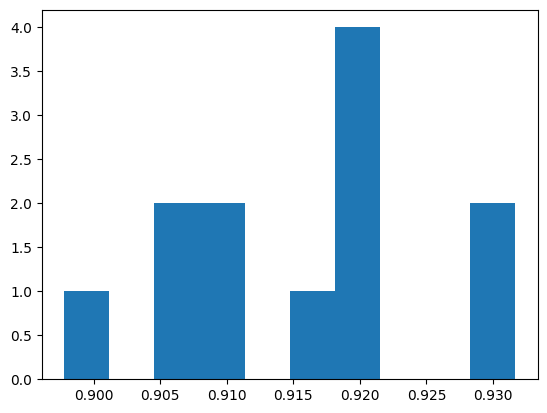

In [ ]:
dict3=pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", return_all_pairs=True)
All_PT3=dict3['All_PTs']
plt.hist(All_PT3['Kd_Fe_Mg_Cpx_Opx'])

In [ ]:
dict2=pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus")


Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
12
Done!!! I found a total of N=1 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:831: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_M = pd.concat([df1_Mean, df1_Std], axis=1).reset_index()
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:936: PerformanceWarning: DataFrame

In [ ]:
All_PT=dict2['All_PTs']
Av_PTs=dict2['Av_PTs_perCPX']

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus").get("Av_PTs_perCPX").Mean_T_K_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!

C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:831: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_M = pd.concat([df1_Mean, df1_Std], axis=1).reset_index()



12
Done!!! I found a total of N=1 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:936: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_M.insert(4, "Equation Choice (T)", str(equationT))
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:942: PerformanceWarning: DataFrame is hi

np.float64(1325.070489121938)

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38",  return_all_pairs=True).get("Av_PTs_perCPX").Mean_T_K_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=4 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=3 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()


np.float64(1311.6940596719433)

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38",  return_all_pairs=True).get("All_PTs").P_kbar_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=4 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=3 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()


np.float64(2.994499997619225)

In [ ]:
df=pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus")

C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:831: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_M = pd.concat([df1_Mean, df1_Std], axis=1).reset_index()


Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
12
Done!!! I found a total of N=1 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:936: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_M.insert(4, "Equation Choice (T)", str(equationT))
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:942: PerformanceWarning: DataFrame is hi

In [ ]:
def test_36_38a_match_KdFiltHT_Temp(self):
        self.assertAlmostEqual(pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus").get("Av_PTs_perCPX")
        .Mean_T_K_calc[0], 1325.070489,
        decimalPlace, "Calc T not equal to test value")

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38",  return_all_pairs=True).get("All_PTs").P_kbar_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=4 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=3 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:862: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_2M = pd.concat([df1_2Mean, df1_2Std], axis=1).reset_index()


np.float64(2.994499997619225)

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus").get("Av_PTs_perCPX")

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
12
Done!!! I found a total of N=1 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:833: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_M = pd.concat([df1_Mean, df1_Std], axis=1).reset_index()
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:904: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1_M.insert(4, "Equation Choice (T)", str(equationT))
C:\PythonPackages_Outside_Box\Thermobar_outsideBox\Thermobar\src\Thermobar\two_pyroxene.py:910: PerformanceWarning: DataFrame is highl

,Sample_ID_Cpx,Mean_T_K_calc,Std_T_K_calc,Mean_P_kbar_calc,Equation Choice (T),Equation Choice (P),Std_P_kbar_calc,ID_CPX,Mean_Kd_Fe_Mg_Cpx_Opx,Mean_Delta_T_K_Iter,Mean_Delta_P_kbar_Iter,Mean_SiO2_Opx,Mean_TiO2_Opx,Mean_Al2O3_Opx,Mean_FeOt_Opx,Mean_MnO_Opx,Mean_MgO_Opx,Mean_CaO_Opx,Mean_Na2O_Opx,Mean_K2O_Opx,Mean_Cr2O3_Opx,Mean_Si_Opx_cat_6ox,Mean_Mg_Opx_cat_6ox,Mean_Fet_Opx_cat_6ox,Mean_Ca_Opx_cat_6ox,Mean_Al_Opx_cat_6ox,Mean_Na_Opx_cat_6ox,Mean_K_Opx_cat_6ox,Mean_Mn_Opx_cat_6ox,Mean_Ti_Opx_cat_6ox,Mean_Cr_Opx_cat_6ox,Mean_oxy_renorm_factor_opx,Mean_Al_IV_Opx_cat_6ox,Mean_Al_VI_Opx_cat_6ox,Mean_Si_Ti_Opx_cat_6ox,Mean_En_Simple_MgFeCa_Opx,Mean_Fs_Simple_MgFeCa_Opx,Mean_Wo_Simple_MgFeCa_Opx,Mean_Cation_Sum_Opx,Mean_Ca_CaMgFe_Opx,Mean_NaAlSi2O6,Mean_FmTiAlSiO6,Mean_CrAl2SiO6,Mean_FmAl2SiO6,Mean_CaFmSi2O6,Mean_Fm2Si2O6,Mean_En_Opx,Mean_Di_Opx,Mean_Mgno_OPX,Mean_ID_OPX,Mean_SiO2_Cpx,Mean_TiO2_Cpx,Mean_Al2O3_Cpx,Mean_FeOt_Cpx,Mean_MnO_Cpx,Mean_MgO_Cpx,Mean_CaO_Cpx,Mean_Na2O_Cpx,Mean_K2O_Cpx,Mean_Cr2O3_Cpx,Mean_Si_Cpx_cat_6ox,Mean_Mg_Cpx_cat_6ox,Mean_Fet_Cpx_cat_6ox,Mean_Ca_Cpx_cat_6ox,Mean_Al_Cpx_cat_6ox,Mean_Na_Cpx_cat_6ox,Mean_K_Cpx_cat_6ox,Mean_Mn_Cpx_cat_6ox,Mean_Ti_Cpx_cat_6ox,Mean_Cr_Cpx_cat_6ox,Mean_oxy_renorm_factor,Mean_Al_IV_cat_6ox,Mean_Al_VI_cat_6ox,Mean_En_Simple_MgFeCa_Cpx,Mean_Fs_Simple_MgFeCa_Cpx,Mean_Wo_Simple_MgFeCa_Cpx,Mean_Cation_Sum_Cpx,Mean_Ca_CaMgFe_Cpx,Mean_Lindley_Fe3_Cpx,Mean_Lindley_Fe2_Cpx,Mean_Lindley_Fe3_Cpx_prop,Mean_CrCaTs,Mean_a_cpx_En,Mean_Mgno_Cpx,"Mean_Jd_from 0=Na, 1=Al",Mean_Jd,Mean_CaTs,Mean_CaTi,Mean_DiHd_1996,Mean_EnFs,Mean_DiHd_2003,Mean_Di_Cpx,Mean_FeIII_Wang21,Mean_FeII_Wang21,Mean_Delta_Kd_Fe_Mg_Cpx_Opx,Std_Kd_Fe_Mg_Cpx_Opx,Std_Delta_T_K_Iter,Std_Delta_P_kbar_Iter,Std_SiO2_Opx,Std_TiO2_Opx,Std_Al2O3_Opx,Std_FeOt_Opx,Std_MnO_Opx,Std_MgO_Opx,Std_CaO_Opx,Std_Na2O_Opx,Std_K2O_Opx,Std_Cr2O3_Opx,Std_Si_Opx_cat_6ox,Std_Mg_Opx_cat_6ox,Std_Fet_Opx_cat_6ox,Std_Ca_Opx_cat_6ox,Std_Al_Opx_cat_6ox,Std_Na_Opx_cat_6ox,Std_K_Opx_cat_6ox,Std_Mn_Opx_cat_6ox,Std_Ti_Opx_cat_6ox,Std_Cr_Opx_cat_6ox,Std_oxy_renorm_factor_opx,Std_Al_IV_Opx_cat_6ox,Std_Al_VI_Opx_cat_6ox,Std_Si_Ti_Opx_cat_6ox,Std_En_Simple_MgFeCa_Opx,Std_Fs_Simple_MgFeCa_Opx,Std_Wo_Simple_MgFeCa_Opx,Std_Cation_Sum_Opx,Std_Ca_CaMgFe_Opx,Std_NaAlSi2O6,Std_FmTiAlSiO6,Std_CrAl2SiO6,Std_FmAl2SiO6,Std_CaFmSi2O6,Std_Fm2Si2O6,Std_En_Opx,Std_Di_Opx,Std_Mgno_OPX,Std_ID_OPX,Std_SiO2_Cpx,Std_TiO2_Cpx,Std_Al2O3_Cpx,Std_FeOt_Cpx,Std_MnO_Cpx,Std_MgO_Cpx,Std_CaO_Cpx,Std_Na2O_Cpx,Std_K2O_Cpx,Std_Cr2O3_Cpx,Std_Si_Cpx_cat_6ox,Std_Mg_Cpx_cat_6ox,Std_Fet_Cpx_cat_6ox,Std_Ca_Cpx_cat_6ox,Std_Al_Cpx_cat_6ox,Std_Na_Cpx_cat_6ox,Std_K_Cpx_cat_6ox,Std_Mn_Cpx_cat_6ox,Std_Ti_Cpx_cat_6ox,Std_Cr_Cpx_cat_6ox,Std_oxy_renorm_factor,Std_Al_IV_cat_6ox,Std_Al_VI_cat_6ox,Std_En_Simple_MgFeCa_Cpx,Std_Fs_Simple_MgFeCa_Cpx,Std_Wo_Simple_MgFeCa_Cpx,Std_Cation_Sum_Cpx,Std_Ca_CaMgFe_Cpx,Std_Lindley_Fe3_Cpx,Std_Lindley_Fe2_Cpx,Std_Lindley_Fe3_Cpx_prop,Std_CrCaTs,Std_a_cpx_En,Std_Mgno_Cpx,"Std_Jd_from 0=Na, 1=Al",Std_Jd,Std_CaTs,Std_CaTi,Std_DiHd_1996,Std_EnFs,Std_DiHd_2003,Std_Di_Cpx,Std_FeIII_Wang21,Std_FeII_Wang21,Std_Delta_Kd_Fe_Mg_Cpx_Opx
0,2,1325.070489,NaN,4.020755,T_Put2008_eq36,P_Put2008_eq38,NaN,2.0,0.897786,0.0,0.0,55.2,0.54,1.7,11.5,0.44,30.9,1.1,0.21,0.2,0.39,1.922848,1.604622,0.335011,0.041056,0.069793,0.014183,0.008888,0.012982,0.014149,0.01074,0.0,0.077152,0.0,1.936997,0.810133,0.169139,0.020728,4.034272,0.020728,0.014183,0.014149,0.01074,0.0,0.041056,0.948706,0.779628,0.033739,0.827276,1.0,48.9,0.2,4.79,5.61,0.065,16.79,20.219,0.219,0.0,0.01,1.854224,0.949101,0.177898,0.821459,0.214065,0.016101,0.0,0.002088,0.005704,0.0003,0.0,0.145776,0.068289,0.487103,0.091302,0.421594,4.04094,0.421594,0.08188,0.096019,0.460262,0.00015,0.143722,0.842144,0.0,0.016101,0.052188,0.046794,0.722327,0.202336,0.722327,0.607182,0.08188,0.096019,0.197786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

(array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 array([0.39778595, 0.49778595, 0.59778595, 0.69778595, 0.79778595,
        0.89778595, 0.99778595, 1.09778595, 1.19778595, 1.29778595,
        1.39778595]),
 <BarContainer object of 10 artists>)

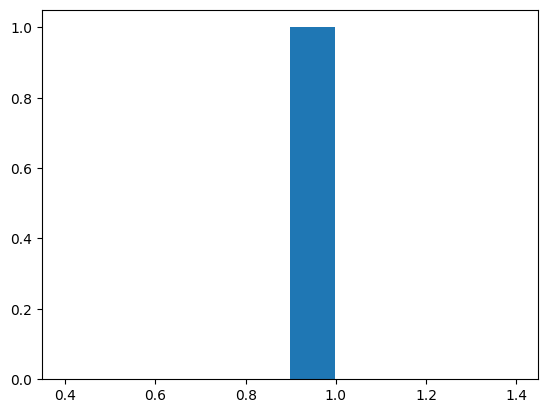

In [ ]:
plt.hist(All_PT['Kd_Fe_Mg_Cpx_Opx'])

In [ ]:
P_Eq38=pt.calculate_cpx_opx_press(opx_comps=OpxT, cpx_comps=CpxT, equationP="P_Put2008_eq38")
P_Eq38.head() # Head shows the first 5 results

100    2.9945
dtype: float64

In [ ]:
P_Eq38=pt.calculate_cpx_opx_press(opx_comps=OpxT, cpx_comps=CpxT, equationP="P_Put2008_eq39", T=1400)
P_Eq38.head() # Head shows the first 5 results

0    4.695694
dtype: float64

In [ ]:
pt.calculate_cpx_opx_temp(opx_comps=OpxT,
            cpx_comps=CpxT, equationT="T_Put2008_eq36", P=3)

0    1305.519026
dtype: float64

In [ ]:
pt.calculate_cpx_opx_temp(opx_comps=OpxT,
            cpx_comps=CpxT, equationT="T_Put2008_eq37", P=3)

0    1317.286386
dtype: float64

In [ ]:
pt.calculate_cpx_opx_temp(opx_comps=OpxT,
            cpx_comps=CpxT, equationT="T_Put2008_eq37", P=3)

0    1317.286386
dtype: float64

In [ ]:
a=pt.calculate_cpx_opx_press_temp(opx_comps=OpxT,
            cpx_comps=CpxT, equationT="T_Put2008_eq36", equationP="P_Put2008_eq39", iterations=5)
a

,P_kbar_calc,T_K_calc,Delta_P_kbar_Iter,Delta_T_K_Iter
0,-0.34275,1288.007901,-0.005181,-0.02668


In [ ]:
pt.calculate_cpx_opx_press_temp(opx_comps=OpxT,
            cpx_comps=CpxT, equationT="T_Put2008_eq36", equationP="P_Put2008_eq38", eq_tests=True)

Youve selected a T-independent function


,T_K_calc,P_kbar_calc,Equation Choice (T),Equation Choice (P),Delta Kd High T,High T Kd Eq?,Delta Kd Low T,Low T Kd Eq?,SiO2_Cpx,TiO2_Cpx,Al2O3_Cpx,FeOt_Cpx,MnO_Cpx,MgO_Cpx,CaO_Cpx,Na2O_Cpx,K2O_Cpx,Cr2O3_Cpx,Si_Cpx_cat_6ox,Mg_Cpx_cat_6ox,Fet_Cpx_cat_6ox,Ca_Cpx_cat_6ox,Al_Cpx_cat_6ox,Na_Cpx_cat_6ox,K_Cpx_cat_6ox,Mn_Cpx_cat_6ox,Ti_Cpx_cat_6ox,Cr_Cpx_cat_6ox,oxy_renorm_factor,Al_IV_cat_6ox,Al_VI_cat_6ox,En_Simple_MgFeCa_Cpx,Fs_Simple_MgFeCa_Cpx,Wo_Simple_MgFeCa_Cpx,Cation_Sum_Cpx,Ca_CaMgFe,Lindley_Fe3_Cpx,Lindley_Fe2_Cpx,Lindley_Fe3_Cpx_prop,CrCaTs,a_cpx_En,Mgno_Cpx,Jd,"Jd_from 0=Na, 1=Al",CaTs,CaTi,DiHd_1996,EnFs,DiHd_2003,Di_Cpx,FeIII_Wang21,FeII_Wang21,SiO2_Opx,TiO2_Opx,Al2O3_Opx,FeOt_Opx,MnO_Opx,MgO_Opx,CaO_Opx,Na2O_Opx,K2O_Opx,Cr2O3_Opx,Si_Opx_cat_6ox,Mg_Opx_cat_6ox,Fet_Opx_cat_6ox,Ca_Opx_cat_6ox,Al_Opx_cat_6ox,Na_Opx_cat_6ox,K_Opx_cat_6ox,Mn_Opx_cat_6ox,Ti_Opx_cat_6ox,Cr_Opx_cat_6ox,oxy_renorm_factor_opx,Al_IV_Opx_cat_6ox,Al_VI_Opx_cat_6ox,Si_Ti_Opx_cat_6ox,En_Simple_MgFeCa_Opx,Fs_Simple_MgFeCa_Opx,Wo_Simple_MgFeCa_Opx,Cation_Sum_Opx,Ca_CaMgFe,NaAlSi2O6,FmTiAlSiO6,CrAl2SiO6,FmAl2SiO6,CaFmSi2O6,Fm2Si2O6,En_Opx,Di_Opx,Mgno_OPX,En,Kd_Fe_Mg_Cpx_Opx,Lindley_Fe3_Opx,a_Di_cpx,Kf,a_En_opx_mod
0,1305.489718,2.9945,T_Put2008_eq36,P_Put2008_eq38,0.171527,N,0.218473,Y,49,0.3,4.89,5.71,0.165,16.89,20.319,0.319,0.1,0.11,1.843671,0.947383,0.179672,0.819149,0.216847,0.023272,0.0048,0.005258,0.008491,0.003272,0.0,0.156329,0.060518,0.486785,0.092319,0.420896,4.051814,0.420896,0.098829,0.080843,0.550053,0.001636,0.13382,0.840579,0.023272,0,0.037247,0.059541,0.720725,0.203165,0.720725,0.603016,0.098829,0.080843,55,0.34,1.5,11.3,0.24,30.7,0.9,0.01,0,0.19,1.943665,1.617356,0.333959,0.034078,0.062475,0.000685,0.0,0.007184,0.009038,0.005308,0.0,0.056335,0.00614,1.952703,0.814628,0.168208,0.017164,4.013748,0.017164,0.000685,0.009038,0.005308,0.000146,0.034078,0.957618,0.790815,0.028142,0.82885,0.859358,0.918473,0.027496,0.601523,0.188431,0.645067


In [ ]:
pt.calculate_cpx_opx_press_temp(opx_comps=OpxT,
        cpx_comps=CpxT, equationT="T_Put2008_eq36", equationP="P_Put2008_eq38").P_kbar_calc[0]

Youve selected a T-independent function


2.994499997619225

## Melt matching

In [ ]:
Cpx_Several=pd.concat([CpxT, CpxT+0.1, CpxT-0.1, CpxT-0.02])
Opx_Several=pd.concat([OpxT, OpxT+0.2, OpxT-0.05])
dict1=pt.calculate_cpx_opx_press_temp_matching(cpx_comps=Cpx_Several, opx_comps=Opx_Several,
                                        equationT="T_Put2008_eq36", equationP="P_Put2008_eq39",
                                               return_all_pairs=True, iterations=3)

#.get("Av_PTs_perCPX")

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", return_all_pairs=True).get("Av_PTs_perCPX").Mean_T_K_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Youve selected a T-independent function
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


1311.4575277220495

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", return_all_pairs=True).get("All_PTs").P_kbar_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Youve selected a T-independent function
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


2.994499997619225

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", return_all_pairs=True).get("Av_PTs_perCPX").Mean_T_K_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Youve selected a T-independent function
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


1311.4575277220495

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match=1, Kd_Err=0.1).get("Av_PTs_perCPX").Mean_T_K_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
Youve selected a T-independent function
Done!!! I found a total of N=11 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


1310.2199857766052

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match=1, Kd_Err=0.1).get("All_PTs")

NameError: name 'Cpx_Several' is not defined

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38",return_all_pairs=True).get("Av_PTs_perCPX").Mean_T_K_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Youve selected a T-independent function
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


1311.4575277220495

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(
        cpx_comps=Cpx_Several, opx_comps=Opx_Several, equationT="T_Put2008_eq36",
        equationP="P_Put2008_eq38", Kd_Match="Subsolidus").get("Av_PTs_perCPX").Mean_T_K_calc[0]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
Youve selected a T-independent function
Done!!! I found a total of N=1 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


1325.070489121938

In [ ]:
pt.calculate_cpx_opx_press_temp_matching(cpx_comps=Cpx_Several, opx_comps=Opx_Several,
                                        equationT="T_Put2008_eq36", equationP="P_Put2008_eq38",
                                        return_all_pairs=True).get("All_PTs")

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Youve selected a T-independent function
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


,Sample_ID_Opx,Sample_ID_Cpx,Kd_Fe_Mg_Cpx_Opx,T_K_calc,P_kbar_calc,Equation Choice (T),Equation Choice (P),SiO2_Opx,TiO2_Opx,Al2O3_Opx,FeOt_Opx,MnO_Opx,MgO_Opx,CaO_Opx,Na2O_Opx,K2O_Opx,Cr2O3_Opx,Si_Opx_cat_6ox,Mg_Opx_cat_6ox,Fet_Opx_cat_6ox,Ca_Opx_cat_6ox,Al_Opx_cat_6ox,Na_Opx_cat_6ox,K_Opx_cat_6ox,Mn_Opx_cat_6ox,Ti_Opx_cat_6ox,Cr_Opx_cat_6ox,oxy_renorm_factor_opx,Al_IV_Opx_cat_6ox,Al_VI_Opx_cat_6ox,Si_Ti_Opx_cat_6ox,En_Simple_MgFeCa_Opx,Fs_Simple_MgFeCa_Opx,Wo_Simple_MgFeCa_Opx,Cation_Sum_Opx,Ca_CaMgFe,Ca_CaMgFe,NaAlSi2O6,FmTiAlSiO6,CrAl2SiO6,FmAl2SiO6,CaFmSi2O6,Fm2Si2O6,En_Opx,Di_Opx,Mgno_OPX,ID_OPX,SiO2_Cpx,TiO2_Cpx,Al2O3_Cpx,FeOt_Cpx,MnO_Cpx,MgO_Cpx,CaO_Cpx,Na2O_Cpx,K2O_Cpx,Cr2O3_Cpx,Si_Cpx_cat_6ox,Mg_Cpx_cat_6ox,Fet_Cpx_cat_6ox,Ca_Cpx_cat_6ox,Al_Cpx_cat_6ox,Na_Cpx_cat_6ox,K_Cpx_cat_6ox,Mn_Cpx_cat_6ox,Ti_Cpx_cat_6ox,Cr_Cpx_cat_6ox,oxy_renorm_factor,Al_IV_cat_6ox,Al_VI_cat_6ox,En_Simple_MgFeCa_Cpx,Fs_Simple_MgFeCa_Cpx,Wo_Simple_MgFeCa_Cpx,Cation_Sum_Cpx,Ca_CaMgFe,Ca_CaMgFe,Lindley_Fe3_Cpx,Lindley_Fe2_Cpx,Lindley_Fe3_Cpx_prop,CrCaTs,a_cpx_En,Mgno_Cpx,Jd,"Jd_from 0=Na, 1=Al",CaTs,CaTi,DiHd_1996,EnFs,DiHd_2003,Di_Cpx,FeIII_Wang21,FeII_Wang21,ID_CPX
0,0,0,0.918473,1305.489718,2.994500,T_Put2008_eq36,P_Put2008_eq38,55.00,0.34,1.50,11.30,0.24,30.70,0.90,0.01,0.00,0.19,1.943665,1.617356,0.333959,0.034078,0.062475,0.000685,0.000000,0.007184,0.009038,0.005308,0.0,0.056335,0.006140,1.952703,0.814628,0.168208,0.017164,4.013748,0.017164,0.420896,0.000685,0.009038,0.005308,0.000146,0.034078,0.957618,0.790815,0.028142,0.828850,0.0,49.00,0.30,4.89,5.71,0.165,16.89,20.319,0.319,0.10,0.11,1.843671,0.947383,0.179672,0.819149,0.216847,0.023272,0.004800,0.005258,0.008491,0.003272,0.0,0.156329,0.060518,0.486785,0.092319,0.420896,4.051814,0.017164,0.420896,0.098829,0.080843,0.550053,0.001636,0.133820,0.840579,0.023272,0.0,0.037247,0.059541,0.720725,0.203165,0.720725,0.603016,0.098829,0.080843,0.0
1,0,0,0.908379,1329.747230,4.087722,T_Put2008_eq36,P_Put2008_eq38,55.20,0.54,1.70,11.50,0.44,30.90,1.10,0.21,0.20,0.39,1.922848,1.604622,0.335011,0.041056,0.069793,0.014183,0.008888,0.012982,0.014149,0.010740,0.0,0.077152,0.000000,1.936997,0.810133,0.169139,0.020728,4.034272,0.020728,0.420896,0.014183,0.014149,0.010740,0.000000,0.041056,0.948706,0.779628,0.033739,0.827276,0.0,49.00,0.30,4.89,5.71,0.165,16.89,20.319,0.319,0.10,0.11,1.843671,0.947383,0.179672,0.819149,0.216847,0.023272,0.004800,0.005258,0.008491,0.003272,0.0,0.156329,0.060518,0.486785,0.092319,0.420896,4.051814,0.020728,0.420896,0.098829,0.080843,0.550053,0.001636,0.133820,0.840579,0.023272,0.0,0.037247,0.059541,0.720725,0.203165,0.720725,0.603016,0.098829,0.080843,0.0
2,0,0,0.921053,1299.845231,2.757122,T_Put2008_eq36,P_Put2008_eq38,54.95,0.29,1.45,11.25,0.19,30.65,0.85,-0.04,-0.05,0.14,1.948964,1.620597,0.333691,0.032302,0.060612,-0.002751,-0.002262,0.005708,0.007737,0.003926,0.0,0.051036,0.009576,1.956701,0.815768,0.167972,0.016260,4.008524,0.016260,0.420896,-0.002751,0.007737,0.003926,0.008401,0.032302,0.955778,0.790273,0.026708,0.829247,0.0,49.00,0.30,4.89,5.71,0.165,16.89,20.319,0.319,0.10,0.11,1.843671,0.947383,0.179672,0.819149,0.216847,0.023272,0.004800,0.005258,0.008491,0.003272,0.0,0.156329,0.060518,0.486785,0.092319,0.420896,4.051814,0.016260,0.420896,0.098829,0.080843,0.550053,0.001636,0.133820,0.840579,0.023272,0.0,0.037247,0.059541,0.720725,0.203165,0.720725,0.603016,0.098829,0.080843,0.0
3,0,0,0.929058,1309.993436,3.073942,T_Put2008_eq36,P_Put2008_eq38,55.00,0.34,1.50,11.30,0.24,30.70,0.90,0.01,0.00,0.19,1.943665,1.617356,0.333959,0.034078,0.062475,0.000685,0.000000,0.007184,0.009038,0.005308,0.0,0.056335,0.006140,1.952703,0.814628,0.168208,0.017164,4.013748,0.017164,0.420206,0.000685,0.009038,0.005308,0.000146,0.034078,0.957618,0.790815,0.028142,0.828850,0.0,49.10,0.40,4.99,5.81,0.265,16.99,20.419,0.419,0.20,0.21,1.833281,0.945691,0.181418,0.816874,0.219586,0.030333,0.009527,0.008381,0.011234,0.006199,0.0,0.166719,0.052867,0.486471,0.093323,0.420206,4.062522,0.017164,0.42

In [ ]:
a=pt.calculate_cpx_opx_press_temp_matching(cpx_comps=Cpx_Several, opx_comps=Opx_Several,
                                        equationT="T_Put2008_eq36", equationP="P_Put2008_eq38",
                                          return_all_pairs=True)
a["Av_PTs_perCPX"]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Youve selected a T-independent function
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


,Sample_ID_Cpx,Mean_T_K_calc,Std_T_K_calc,Mean_P_kbar_calc,Std_P_kbar_calc,ID_CPX,Mean_Kd_Fe_Mg_Cpx_Opx,Mean_SiO2_Opx,Mean_TiO2_Opx,Mean_Al2O3_Opx,Mean_FeOt_Opx,Mean_MnO_Opx,Mean_MgO_Opx,Mean_CaO_Opx,Mean_Na2O_Opx,Mean_K2O_Opx,Mean_Cr2O3_Opx,Mean_Si_Opx_cat_6ox,Mean_Mg_Opx_cat_6ox,Mean_Fet_Opx_cat_6ox,Mean_Ca_Opx_cat_6ox,Mean_Al_Opx_cat_6ox,Mean_Na_Opx_cat_6ox,Mean_K_Opx_cat_6ox,Mean_Mn_Opx_cat_6ox,Mean_Ti_Opx_cat_6ox,Mean_Cr_Opx_cat_6ox,Mean_oxy_renorm_factor_opx,Mean_Al_IV_Opx_cat_6ox,Mean_Al_VI_Opx_cat_6ox,Mean_Si_Ti_Opx_cat_6ox,Mean_En_Simple_MgFeCa_Opx,Mean_Fs_Simple_MgFeCa_Opx,Mean_Wo_Simple_MgFeCa_Opx,Mean_Cation_Sum_Opx,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_NaAlSi2O6,Mean_FmTiAlSiO6,Mean_CrAl2SiO6,Mean_FmAl2SiO6,Mean_CaFmSi2O6,Mean_Fm2Si2O6,Mean_En_Opx,Mean_Di_Opx,Mean_Mgno_OPX,Mean_ID_OPX,Mean_SiO2_Cpx,Mean_TiO2_Cpx,Mean_Al2O3_Cpx,Mean_FeOt_Cpx,Mean_MnO_Cpx,Mean_MgO_Cpx,Mean_CaO_Cpx,Mean_Na2O_Cpx,Mean_K2O_Cpx,Mean_Cr2O3_Cpx,Mean_Si_Cpx_cat_6ox,Mean_Mg_Cpx_cat_6ox,Mean_Fet_Cpx_cat_6ox,Mean_Ca_Cpx_cat_6ox,Mean_Al_Cpx_cat_6ox,Mean_Na_Cpx_cat_6ox,Mean_K_Cpx_cat_6ox,Mean_Mn_Cpx_cat_6ox,Mean_Ti_Cpx_cat_6ox,Mean_Cr_Cpx_cat_6ox,Mean_oxy_renorm_factor,Mean_Al_IV_cat_6ox,Mean_Al_VI_cat_6ox,Mean_En_Simple_MgFeCa_Cpx,Mean_Fs_Simple_MgFeCa_Cpx,Mean_Wo_Simple_MgFeCa_Cpx,Mean_Cation_Sum_Cpx,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Lindley_Fe3_Cpx,Mean_Lindley_Fe2_Cpx,Mean_Lindley_Fe3_Cpx_prop,Mean_CrCaTs,Mean_a_cpx_En,Mean_Mgno_Cpx,Mean_Jd,"Mean_Jd_from 0=Na, 1=Al",Mean_CaTs,Mean_CaTi,Mean_DiHd_1996,Mean_EnFs,Mean_DiHd_2003,Mean_Di_Cpx,Mean_FeIII_Wang21,Mean_FeII_Wang21,Std_Kd_Fe_Mg_Cpx_Opx,Std_SiO2_Opx,Std_TiO2_Opx,Std_Al2O3_Opx,Std_FeOt_Opx,Std_MnO_Opx,Std_MgO_Opx,Std_CaO_Opx,Std_Na2O_Opx,Std_K2O_Opx,Std_Cr2O3_Opx,Std_Si_Opx_cat_6ox,Std_Mg_Opx_cat_6ox,Std_Fet_Opx_cat_6ox,Std_Ca_Opx_cat_6ox,Std_Al_Opx_cat_6ox,Std_Na_Opx_cat_6ox,Std_K_Opx_cat_6ox,Std_Mn_Opx_cat_6ox,Std_Ti_Opx_cat_6ox,Std_Cr_Opx_cat_6ox,Std_oxy_renorm_factor_opx,Std_Al_IV_Opx_cat_6ox,Std_Al_VI_Opx_cat_6ox,Std_Si_Ti_Opx_cat_6ox,Std_En_Simple_MgFeCa_Opx,Std_Fs_Simple_MgFeCa_Opx,Std_Wo_Simple_MgFeCa_Opx,Std_Cation_Sum_Opx,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_NaAlSi2O6,Std_FmTiAlSiO6,Std_CrAl2SiO6,Std_FmAl2SiO6,Std_CaFmSi2O6,Std_Fm2Si2O6,Std_En_Opx,Std_Di_Opx,Std_Mgno_OPX,Std_ID_OPX,Std_SiO2_Cpx,Std_TiO2_Cpx,Std_Al2O3_Cpx,Std_FeOt_Cpx,Std_MnO_Cpx,Std_MgO_Cpx,Std_CaO_Cpx,Std_Na2O_Cpx,Std_K2O_Cpx,Std_Cr2O3_Cpx,Std_Si_Cpx_cat_6ox,Std_Mg_Cpx_cat_6ox,Std_Fet_Cpx_cat_6ox,Std_Ca_Cpx_cat_6ox,Std_Al_Cpx_cat_6ox,Std_Na_Cpx_cat_6ox,Std_K_Cpx_cat_6ox,Std_Mn_Cpx_cat_6ox,Std_Ti_Cpx_cat_6ox,Std_Cr_Cpx_cat_6ox,Std_oxy_renorm_factor,Std_Al_IV_cat_6ox,Std_Al_VI_cat_6ox,Std_En_Simple_MgFeCa_Cpx,Std_Fs_Simple_MgFeCa_Cpx,Std_Wo_Simple_MgFeCa_Cpx,Std_Cation_Sum_Cpx,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Lindley_Fe3_Cpx,Std_Lindley_Fe2_Cpx,Std_Lindley_Fe3_Cpx_prop,Std_CrCaTs,Std_a_cpx_En,Std_Mgno_Cpx,Std_Jd,"Std_Jd_from 0=Na, 1=Al",Std_CaTs,Std_CaTi,Std_DiHd_1996,Std_EnFs,Std_DiHd_2003,Std_Di_Cpx,Std_FeIII_Wang21,Std_FeII_Wang21
0,0,1311.457528,13.962876,3.275629,0.608386,0.0,0.915405,55.05,0.39,1.55,11.35,0.29,30.75,0.95,0.06,0.05,0.24,1.938492,1.614192,0.33422,0.035812,0.064293,0.004039,0.002208,0.008625,0.010308,0.006658,0.0,0.061508,0.005239,1.9488,0.81351,0.16844,0.018051,4.018848,0.018051,0.420933,0.018051,0.420933,0.018051,0.420933,0.018051,0.420933,0.004039,0.010308,0.006658,0.002849,0.035812,0.954034,0.786905,0.02953,0.828458,0.0,48.995,0.295,4.885,5.705,0.16,16.885,20.314,0.314,0.095,0.105,1.844236,0.947475,0.179577,0.819273,0.216698,0.022888,0.004543,0.005089,0.008341,0.003113,0.0,0.155764,0.060934,0.486802,0.092265,0.420933,4.051232,0.018051,0.420933,0.018051,0

In [ ]:
a=pt.calculate_cpx_opx_press_temp_matching(cpx_comps=Cpx_Several, opx_comps=Opx_Several,
                                        equationT="T_Put2008_eq36", equationP="P_Put2008_eq38",
                                         return_all_pairs=True)

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
No Kd selected, all matches are shown
Youve selected a T-independent function
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


In [ ]:
a=pt.calculate_cpx_opx_press_temp_matching(cpx_comps=Cpx_Several, opx_comps=Opx_Several,
                                        equationT="T_Put2008_eq36", equationP="P_Put2008_eq38", Kd_Match=1, Kd_Err=0.12)
a["Av_PTs_perCPX"]

Considering N=4 Cpx & N=3 Opx, which is a total of N=12 Cpx-Opx pairs, be patient if this is >>1 million!
Youve selected a T-independent function
Done!!! I found a total of N=12 Cpx-Opx matches using the specified filter. 
N=1 Cpx out of the N=4 Cpx that you input matched to 1 or more Opx
N=1 Opx out of the N=3 Opx that you input matched to 1 or more Cpx
Done!


,Sample_ID_Cpx,Mean_T_K_calc,Std_T_K_calc,Mean_P_kbar_calc,Std_P_kbar_calc,ID_CPX,Mean_Kd_Fe_Mg_Cpx_Opx,Mean_SiO2_Opx,Mean_TiO2_Opx,Mean_Al2O3_Opx,Mean_FeOt_Opx,Mean_MnO_Opx,Mean_MgO_Opx,Mean_CaO_Opx,Mean_Na2O_Opx,Mean_K2O_Opx,Mean_Cr2O3_Opx,Mean_Si_Opx_cat_6ox,Mean_Mg_Opx_cat_6ox,Mean_Fet_Opx_cat_6ox,Mean_Ca_Opx_cat_6ox,Mean_Al_Opx_cat_6ox,Mean_Na_Opx_cat_6ox,Mean_K_Opx_cat_6ox,Mean_Mn_Opx_cat_6ox,Mean_Ti_Opx_cat_6ox,Mean_Cr_Opx_cat_6ox,Mean_oxy_renorm_factor_opx,Mean_Al_IV_Opx_cat_6ox,Mean_Al_VI_Opx_cat_6ox,Mean_Si_Ti_Opx_cat_6ox,Mean_En_Simple_MgFeCa_Opx,Mean_Fs_Simple_MgFeCa_Opx,Mean_Wo_Simple_MgFeCa_Opx,Mean_Cation_Sum_Opx,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_NaAlSi2O6,Mean_FmTiAlSiO6,Mean_CrAl2SiO6,Mean_FmAl2SiO6,Mean_CaFmSi2O6,Mean_Fm2Si2O6,Mean_En_Opx,Mean_Di_Opx,Mean_Mgno_OPX,Mean_ID_OPX,Mean_SiO2_Cpx,Mean_TiO2_Cpx,Mean_Al2O3_Cpx,Mean_FeOt_Cpx,Mean_MnO_Cpx,Mean_MgO_Cpx,Mean_CaO_Cpx,Mean_Na2O_Cpx,Mean_K2O_Cpx,Mean_Cr2O3_Cpx,Mean_Si_Cpx_cat_6ox,Mean_Mg_Cpx_cat_6ox,Mean_Fet_Cpx_cat_6ox,Mean_Ca_Cpx_cat_6ox,Mean_Al_Cpx_cat_6ox,Mean_Na_Cpx_cat_6ox,Mean_K_Cpx_cat_6ox,Mean_Mn_Cpx_cat_6ox,Mean_Ti_Cpx_cat_6ox,Mean_Cr_Cpx_cat_6ox,Mean_oxy_renorm_factor,Mean_Al_IV_cat_6ox,Mean_Al_VI_cat_6ox,Mean_En_Simple_MgFeCa_Cpx,Mean_Fs_Simple_MgFeCa_Cpx,Mean_Wo_Simple_MgFeCa_Cpx,Mean_Cation_Sum_Cpx,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Ca_CaMgFe,Mean_Lindley_Fe3_Cpx,Mean_Lindley_Fe2_Cpx,Mean_Lindley_Fe3_Cpx_prop,Mean_CrCaTs,Mean_a_cpx_En,Mean_Mgno_Cpx,Mean_Jd,"Mean_Jd_from 0=Na, 1=Al",Mean_CaTs,Mean_CaTi,Mean_DiHd_1996,Mean_EnFs,Mean_DiHd_2003,Mean_Di_Cpx,Mean_FeIII_Wang21,Mean_FeII_Wang21,Mean_Delta_Kd_Fe_Mg_Cpx_Opx,Std_Kd_Fe_Mg_Cpx_Opx,Std_SiO2_Opx,Std_TiO2_Opx,Std_Al2O3_Opx,Std_FeOt_Opx,Std_MnO_Opx,Std_MgO_Opx,Std_CaO_Opx,Std_Na2O_Opx,Std_K2O_Opx,Std_Cr2O3_Opx,Std_Si_Opx_cat_6ox,Std_Mg_Opx_cat_6ox,Std_Fet_Opx_cat_6ox,Std_Ca_Opx_cat_6ox,Std_Al_Opx_cat_6ox,Std_Na_Opx_cat_6ox,Std_K_Opx_cat_6ox,Std_Mn_Opx_cat_6ox,Std_Ti_Opx_cat_6ox,Std_Cr_Opx_cat_6ox,Std_oxy_renorm_factor_opx,Std_Al_IV_Opx_cat_6ox,Std_Al_VI_Opx_cat_6ox,Std_Si_Ti_Opx_cat_6ox,Std_En_Simple_MgFeCa_Opx,Std_Fs_Simple_MgFeCa_Opx,Std_Wo_Simple_MgFeCa_Opx,Std_Cation_Sum_Opx,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_NaAlSi2O6,Std_FmTiAlSiO6,Std_CrAl2SiO6,Std_FmAl2SiO6,Std_CaFmSi2O6,Std_Fm2Si2O6,Std_En_Opx,Std_Di_Opx,Std_Mgno_OPX,Std_ID_OPX,Std_SiO2_Cpx,Std_TiO2_Cpx,Std_Al2O3_Cpx,Std_FeOt_Cpx,Std_MnO_Cpx,Std_MgO_Cpx,Std_CaO_Cpx,Std_Na2O_Cpx,Std_K2O_Cpx,Std_Cr2O3_Cpx,Std_Si_Cpx_cat_6ox,Std_Mg_Cpx_cat_6ox,Std_Fet_Cpx_cat_6ox,Std_Ca_Cpx_cat_6ox,Std_Al_Cpx_cat_6ox,Std_Na_Cpx_cat_6ox,Std_K_Cpx_cat_6ox,Std_Mn_Cpx_cat_6ox,Std_Ti_Cpx_cat_6ox,Std_Cr_Cpx_cat_6ox,Std_oxy_renorm_factor,Std_Al_IV_cat_6ox,Std_Al_VI_cat_6ox,Std_En_Simple_MgFeCa_Cpx,Std_Fs_Simple_MgFeCa_Cpx,Std_Wo_Simple_MgFeCa_Cpx,Std_Cation_Sum_Cpx,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Ca_CaMgFe,Std_Lindley_Fe3_Cpx,Std_Lindley_Fe2_Cpx,Std_Lindley_Fe3_Cpx_prop,Std_CrCaTs,Std_a_cpx_En,Std_Mgno_Cpx,Std_Jd,"Std_Jd_from 0=Na, 1=Al",Std_CaTs,Std_CaTi,Std_DiHd_1996,Std_EnFs,Std_DiHd_2003,Std_Di_Cpx,Std_FeIII_Wang21,Std_FeII_Wang21,Std_Delta_Kd_Fe_Mg_Cpx_Opx
0,0,1311.457528,13.962876,3.275629,0.608386,0.0,0.915405,55.05,0.39,1.55,11.35,0.29,30.75,0.95,0.06,0.05,0.24,1.938492,1.614192,0.33422,0.035812,0.064293,0.004039,0.002208,0.008625,0.010308,0.006658,0.0,0.061508,0.005239,1.9488,0.81351,0.16844,0.018051,4.018848,0.018051,0.420933,0.018051,0.420933,0.018051,0.420933,0.018051,0.420933,0.004039,0.010308,0.006658,0.002849,0.035812,0.954034,0.786905,0.02953,0.828458,0.0,48.995,0.295,4.885,5.705,0.16,16.885,20.314,0.314,0.095,0.105,1.844236,0.947475,0.179577,0.819273,0.216698,0.022888,0.004543,0.005089,0.008341,0.003113,0.0,0.155764,0.060934,0.486802,

In [ ]:
a=pt.calculate_cpx_opx_press_temp_matching(cpx_comps=Cpx_Several, opx_comps=Opx_Several,
                                        equationT="T_Put2008_eq36", equationP="P_Put2008_eq38", Kd_Match="Subsolidus")
a["Av_PTs_perCPX"]

Considering 12 Liq-Cpx pairs, be patient if this is >>1 million!


..\Thermobar\two_pyroxene.py:266: UserWarning: Youve selected a T-independent function, so your T input doesnt do anything
  w.warn('Youve selected a T-independent function, so your T input doesnt do anything')


Finished calculating Ps and Ts, now just averaging the results. Almost there!
Done!


,Mean_Sample_ID_Cpx,st_dev_T_K_calc,Mean_T_K_calc,st_dev_P_kbar_calc,Equation Choice (T),Equation Choice (P),Mean_P_kbar_calc,Mean_Sample_ID_Opx,Mean_Kd_Fe_Mg_Cpx_Opx,Mean_SiO2_Opx,Mean_TiO2_Opx,Mean_Al2O3_Opx,Mean_FeOt_Opx,Mean_MnO_Opx,Mean_MgO_Opx,Mean_CaO_Opx,Mean_Na2O_Opx,Mean_K2O_Opx,Mean_Cr2O3_Opx,Mean_SiO2_Opx_cat_6ox,Mean_MgO_Opx_cat_6ox,Mean_FeOt_Opx_cat_6ox,Mean_CaO_Opx_cat_6ox,Mean_Al2O3_Opx_cat_6ox,Mean_Na2O_Opx_cat_6ox,Mean_K2O_Opx_cat_6ox,Mean_MnO_Opx_cat_6ox,Mean_TiO2_Opx_cat_6ox,Mean_Cr2O3_Opx_cat_6ox,Mean_oxy_renorm_factor_opx,Mean_Al_IV_Opx_cat_6ox,Mean_Al_VI_Opx_cat_6ox,Mean_Si_Ti_Opx_cat_6ox,Mean_Cation_Sum_Opx,Mean_NaAlSi2O6,Mean_FmTiAlSiO6,Mean_CrAl2SiO6,Mean_FmAl2SiO6,Mean_CaFmSi2O6,Mean_Fm2Si2O6,Mean_En_Opx,Mean_Di_Opx,Mean_Mgno_OPX,Mean_ID_OPX,Mean_SiO2_Cpx,Mean_TiO2_Cpx,Mean_Al2O3_Cpx,Mean_FeOt_Cpx,Mean_MnO_Cpx,Mean_MgO_Cpx,Mean_CaO_Cpx,Mean_Na2O_Cpx,Mean_K2O_Cpx,Mean_Cr2O3_Cpx,Mean_SiO2_Cpx_cat_6ox,Mean_MgO_Cpx_cat_6ox,Mean_FeOt_Cpx_cat_6ox,Mean_CaO_Cpx_cat_6ox,Mean_Al2O3_Cpx_cat_6ox,Mean_Na2O_Cpx_cat_6ox,Mean_K2O_Cpx_cat_6ox,Mean_MnO_Cpx_cat_6ox,Mean_TiO2_Cpx_cat_6ox,Mean_Cr2O3_Cpx_cat_6ox,Mean_oxy_renorm_factor,Mean_Al_IV_cat_6ox,Mean_Al_VI_cat_6ox,Mean_Cation_Sum_Cpx,Mean_CrCaTs,Mean_a_cpx_En,Mean_Mgno_CPX,Mean_Jd,Mean_CaTs,Mean_CaTi,Mean_DiHd_1996,Mean_EnFs,Mean_DiHd_2003,Mean_Di_Cpx,Mean_ID_CPX,Mean_Delta_Kd_Fe_Mg_Cpx_Opx
0,0,0.0,1325.070489,0.0,T_Put2008_eq36,P_Put2008_eq38,4.020755,0.0,0.897786,55.2,0.54,1.7,11.5,0.44,30.9,1.1,0.21,0.2,0.39,1.922848,1.604622,0.335011,0.041056,0.069793,0.014183,0.008888,0.012982,0.014149,0.01074,0.0,0.077152,0.0,1.936997,4.034272,0.014183,0.014149,0.01074,0.0,0.041056,0.948706,0.779628,0.033739,0.827276,0.0,48.9,0.2,4.79,5.61,0.065,16.79,20.219,0.219,0.0,0.01,1.854224,0.949101,0.177898,0.821459,0.214065,0.016101,0.0,0.002088,0.005704,0.0003,0.0,0.145776,0.068289,4.04094,0.00015,0.143722,0.842144,0.016101,0.052188,0.046794,0.722327,0.202336,0.722327,0.607182,0.0,0.197786
